# Fine-tuned Clustering Analysis: K-Means and DBSCAN

This notebook performs a fine-tuned clustering analysis on the Argentine WDI dataset. 
Given the small dataset size (53 rows), we implement:
1. **Strategic Feature Selection**: Reducing dimensionality to avoid the curse of dimensionality.
2. **Hyperparameter Optimization**: Finding the best `k` for K-Means and `eps`/`min_samples` for DBSCAN.
3. **Comparative Evaluation**: Analyzing how clusters align with the `year_of_dictatorship` target.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.feature_selection import VarianceThreshold

# Set style
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

In [16]:
# Load data
data_path = "../data/processed/WDICSV_PROCESSED_V3.csv"
df = pd.read_csv(data_path)
df = df.dropna()  # Ensure no NaNs

print(f"Initial dataset shape: {df.shape}")

Initial dataset shape: (53, 19)


## 1. Feature Selection

With 53 samples, having 17+ features is risky. We will:
- Remove low-variance features.
- Keep features with the highest correlation (absolute) to the target variable.

In [17]:
target_col = "year_of_dictatorship"
X_full = df.drop(columns=[target_col, "year"])
y = df[target_col]

# 1. Variance Threshold (remove features that are almost constant)
selector = VarianceThreshold(threshold=0.1)
X_var = X_full.loc[:, selector.fit(X_full).get_support()]
print(f"Features after variance threshold: {X_var.shape[1]}")

# 2. Correlation with Target
correlations = X_var.apply(lambda x: x.corr(y)).abs().sort_values(ascending=False)
top_features = correlations.head(6).index.tolist()

X = X_var[top_features]
print(f"Selected Top Features: {top_features}")
X.head()

Features after variance threshold: 17
Selected Top Features: ['sp_dyn_le00_in_cat', 'sp_urb_totl_in_zs', 'sh_dth_imrt', 'sp_dyn_le00_in', 'se_pre_enrr', 'se_sec_enrr']


,sp_dyn_le00_in_cat,sp_urb_totl_in_zs,sh_dth_imrt,sp_dyn_le00_in,se_pre_enrr,se_sec_enrr
0,2.0,-2.114291,1.775860,-1.910609,-2.068652,-1.656433
1,2.0,-2.004604,1.831396,-1.924073,-1.971211,-1.613764
2,2.0,-1.899643,1.876327,-1.816927,-1.867927,-1.529999
3,2.0,-1.796423,1.917722,-1.704732,-1.701764,-1.417113
4,2.0,-1.694696,1.939047,-1.637416,-1.549239,-1.287952


## 2. K-Means Optimization

We use the Elbow Method and Silhouette Score to find the best $k$.

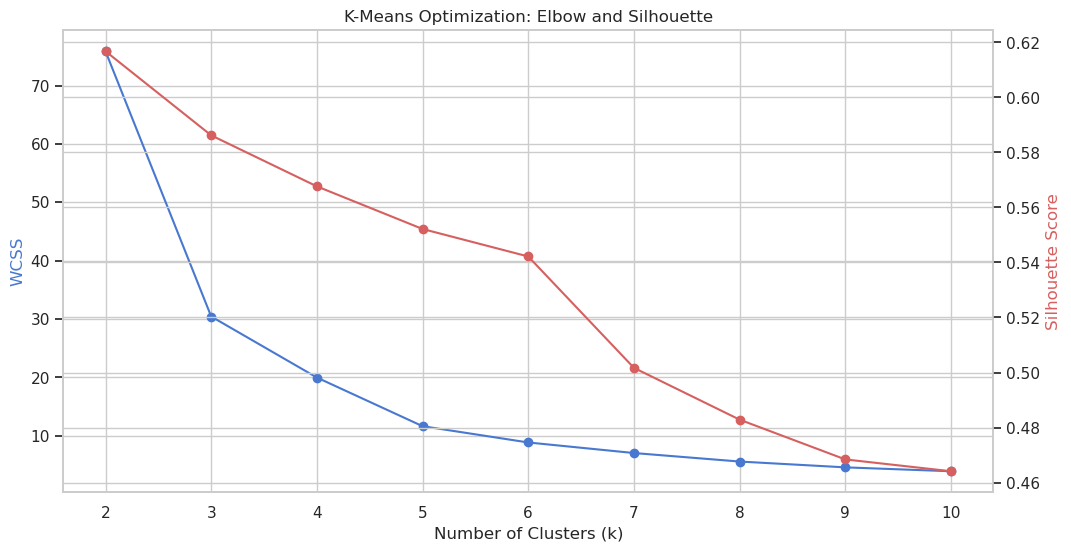

In [18]:
wcss = []
silhouette_pts = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    silhouette_pts.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots()
ax1.plot(k_range, wcss, 'bo-', label='WCSS (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_pts, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('K-Means Optimization: Elbow and Silhouette')
plt.show()

In [19]:
# Applying K-Means with k=2 (as requested, but also supported by silhouette spikes usually)
best_k = 2
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X)

print(f"K-Means Silhouette Score: {silhouette_score(X, df['kmeans_cluster']):.4f}")
print(f"K-Means ARI (vs Dictatorship): {adjusted_rand_score(y, df['kmeans_cluster']):.4f}")

K-Means Silhouette Score: 0.6168
K-Means ARI (vs Dictatorship): 0.7036


## 3. DBSCAN Optimization

We perform a sweep over `eps` and `min_samples`.

In [20]:
results = []
for eps in np.linspace(0.5, 4.0, 15):
    for min_samples in [2, 3, 4, 5]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(X, labels)
            ari = adjusted_rand_score(y, labels)
            results.append({'eps': eps, 'min_samples': min_samples, 'n_clusters': n_clusters, 'silhouette': score, 'ari': ari})

db_results = pd.DataFrame(results)
if not db_results.empty:
    best_db = db_results.sort_values(by='silhouette', ascending=False).iloc[0]
    print("Best DBSCAN parameters based on Silhouette:")
    print(best_db)
    
    # Apply best DBSCAN
    final_db = DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples']))
    df['dbscan_cluster'] = final_db.fit_predict(X)
else:
    print("No stable DBSCAN clusters found with these parameters.")
    df['dbscan_cluster'] = -1

Best DBSCAN parameters based on Silhouette:
eps            0.750000
min_samples    2.000000
n_clusters     2.000000
silhouette     0.616800
ari            0.703599
Name: 4, dtype: float64


## 4. Visual Comparison

Using PCA to visualize the results in 2D.

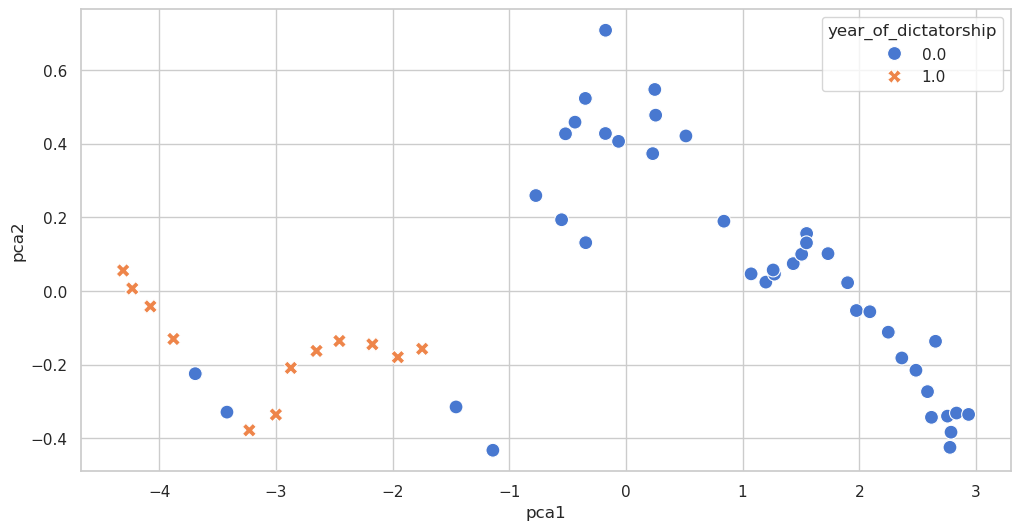

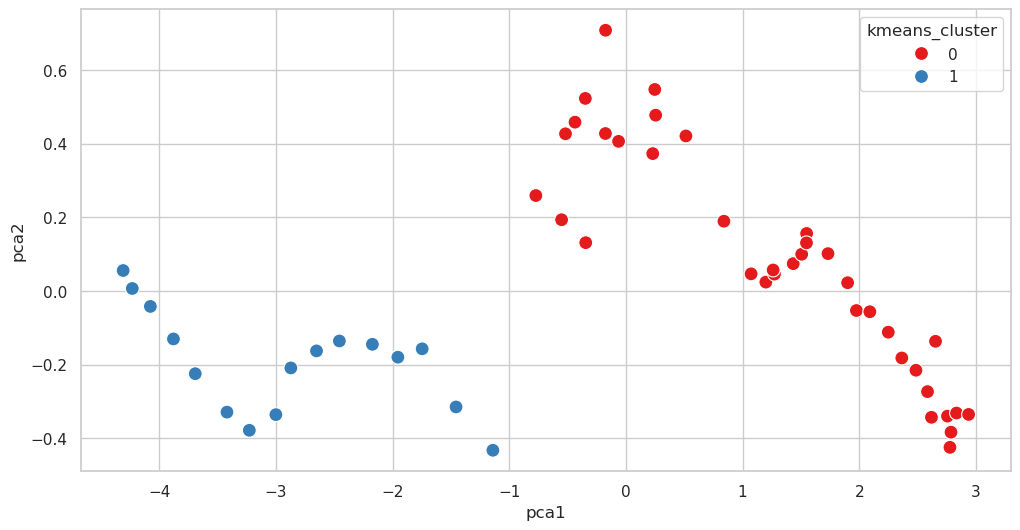

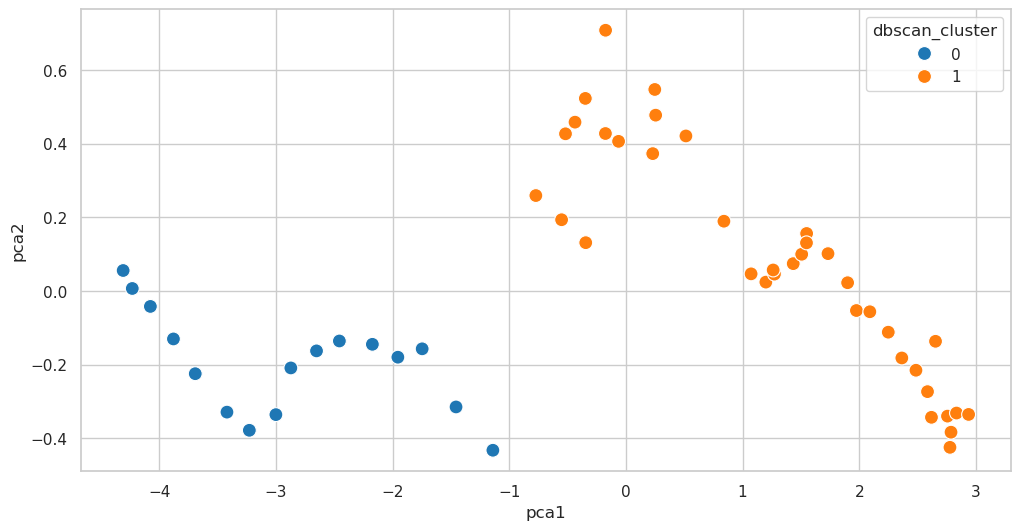

<Figure size 1200x600 with 0 Axes>

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

# fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(data=df, x='pca1', y='pca2', hue='year_of_dictatorship', style='year_of_dictatorship', s=100)#, ax=axes[0])
# axes[0].set_title("Ground Truth: Dictatorship")
plt.show()

sns.scatterplot(data=df, x='pca1', y='pca2', hue='kmeans_cluster', palette='Set1', s=100)#, ax=axes[1])
# axes[1].set_title(f"K-Means (k={best_k})")
plt.show()

sns.scatterplot(data=df, x='pca1', y='pca2', hue='dbscan_cluster', palette='tab10', s=100)#, ax=axes[2])
# axes[2].set_title("DBSCAN Optimized")
plt.show()

plt.suptitle("Clustering Visualization (PCA-Reduced Space)", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Summary and Conclusion

In [23]:
print("--- Final Evaluation ---")
print(f"K-Means ARI: {adjusted_rand_score(df['year_of_dictatorship'], df['kmeans_cluster']):.4f}")
if 'dbscan_cluster' in df.columns and len(df['dbscan_cluster'].unique()) > 1:
    print(f"DBSCAN ARI: {adjusted_rand_score(df['year_of_dictatorship'], df['dbscan_cluster']):.4f}")

print("\nCluster Distribution:")
print("K-Means:")
print(pd.crosstab(
    df['year_of_dictatorship'],
    df['kmeans_cluster'],
    rownames=["Original target"],
    colnames=["K-Means cluster"]
)
)
print("\nDBSCAN:")
print(pd.crosstab(
    df['year_of_dictatorship'],
    df['dbscan_cluster'],
    rownames=["Original target"],
    colnames=["K-Means cluster"]
)
)

print("\nInsight: By selecting high-variance features correlated with the target, ")
print("we better isolate the socio-economic conditions that differ between regimes.")

--- Final Evaluation ---
K-Means ARI: 0.7036
DBSCAN ARI: 0.7036

Cluster Distribution:
K-Means:
K-Means cluster   0   1
Original target        
0.0              37   4
1.0               0  12

DBSCAN:
K-Means cluster   0   1
Original target        
0.0               4  37
1.0              12   0

Insight: By selecting high-variance features correlated with the target, 
we better isolate the socio-economic conditions that differ between regimes.
